# 03 - Train Baseline XGBoost Model

Note: the plan named this `notebooks/02_train_model.ipynb`, but `02` is
already taken by `02_feature_engineering.ipynb` -- named this `03_` instead
to keep the notebook sequence in order rather than overwrite or collide
with it.

In [1]:
import sys

sys.path.insert(0, "..")  # so `app.services.feature_pipeline` is importable from notebooks/

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

from app.services.feature_pipeline import build_features

## Load data and build features

Reuse the exact same `build_features()` used for EDA/feature engineering
(`app/services/feature_pipeline.py`) rather than reimplementing the logic
here -- the whole point of moving it into a module was so training and
serving never drift apart.

In [2]:
raw = pd.read_csv("../data/raw/churn_data.csv")
df = build_features(raw)

X = df.drop(columns=["churn_flag"])
y = df["churn_flag"]

print("X shape:", X.shape)
print("y churn rate:", y.mean().round(4))

X shape: (7043, 20)
y churn rate: 0.2654


## Train/test split

`stratify=y` keeps the ~26.5% churn rate consistent across both splits --
without it, a random split could easily skew the test set's class balance
enough to make the accuracy trap below even more misleading than it
already is.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape, " Train churn rate:", y_train.mean().round(4))
print("Test shape: ", X_test.shape, " Test churn rate: ", y_test.mean().round(4))

Train shape: (5634, 20)  Train churn rate: 0.2654
Test shape:  (1409, 20)  Test churn rate:  0.2654


## Why XGBoost for this problem

XGBoost is the standard default for tabular churn problems like this one:
- The Telco feature set is mostly categorical (contract type, payment
  method, internet service, etc., now one-hot/ordinal encoded) -- tree
  splits handle that natively, no need for the model to learn smooth
  numeric relationships that aren't really there.
- It captures non-linear interactions (e.g. "month-to-month contract *and*
  electronic check *and* low tenure" compounding risk) automatically,
  without hand-built interaction terms.
- Fast to train at this scale (7k rows, ~20 features) -- a full run takes
  seconds, which matters for iterating on features/hyperparameters.

In [4]:
model = XGBClassifier(random_state=42, eval_metric="logloss")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Model trained.")

Model trained.


## Accuracy -- and why not to trust it yet

Churn rate is ~26.5%, so a model that predicts "No" for every single
customer would score roughly **73.5% accuracy while learning nothing at
all**. Printing accuracy below alongside that naive baseline, specifically
so the trap is visible in the same cell rather than looking like a real
result on its own -- if the model's accuracy is only a few points above
the naive baseline, it's not actually doing much. Precision/recall (next
step) is what will actually reveal whether it's catching churners, which
is the only thing this model is for.

In [5]:
naive_baseline_accuracy = max(y_test.mean(), 1 - y_test.mean())
model_accuracy = accuracy_score(y_test, y_pred)

print(f"Naive 'always predict majority class' accuracy: {naive_baseline_accuracy:.4f}")
print(f"XGBoost model accuracy:                         {model_accuracy:.4f}")
print(f"Lift over naive baseline:                        {model_accuracy - naive_baseline_accuracy:+.4f}")

Naive 'always predict majority class' accuracy: 0.7346
XGBoost model accuracy:                         0.7842
Lift over naive baseline:                        +0.0497


## Handling class imbalance

A model trained on this data as-is has every incentive to just predict
"No churn" for everyone -- it's right 73.5% of the time for free, and
gradient boosting minimizes average loss across all training examples, so
the majority class dominates that average. The model above already shows
early signs of this (only +5 points over the naive baseline). Two standard
fixes:

- **`scale_pos_weight`** (XGBoost's built-in class-weighting parameter):
  multiplies the gradient/loss contribution of positive (churn) examples,
  so misclassifying a churner costs the model more than misclassifying a
  non-churner. No new data, no extra pipeline step -- just one parameter.
- **SMOTE** (Synthetic Minority Oversampling): generates synthetic
  minority-class (churn) examples by interpolating between real minority
  samples and their nearest neighbors, until the training set is balanced.
  Adds real (if synthetic) rows rather than reweighting existing ones.

Compare both against the unweighted baseline above, on precision/recall/
PR-AUC -- accuracy is exactly the metric the sheet already warned not to
trust here.

In [6]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    classification_report,
)


def evaluate(name, y_true, y_pred, y_proba):
    """One place to compute the same metric set for every approach below,
    so baseline/scale_pos_weight/SMOTE are compared on identical terms."""
    return {
        "approach": name,
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "pr_auc": average_precision_score(y_true, y_proba),
    }


results = []

# Baseline: the unweighted model trained above -- the precision/recall
# follow-through promised in that section's own notes.
baseline_proba = model.predict_proba(X_test)[:, 1]
results.append(evaluate("baseline (no imbalance handling)", y_test, y_pred, baseline_proba))
print("Baseline:")
print(classification_report(y_test, y_pred, target_names=["No churn", "Churn"]))

Baseline:
              precision    recall  f1-score   support

    No churn       0.83      0.89      0.86      1035
       Churn       0.61      0.51      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.70      0.71      1409
weighted avg       0.77      0.78      0.78      1409



## Approach 1: `scale_pos_weight`

`scale_pos_weight = count(negative) / count(positive)`, computed from the
*training* split only (never the full dataset or the test set -- that
would leak test-set class balance into training). This comes out close to
the sheet's estimate of ~2.8 from the overall 73.5/26.5 split.

In [7]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight = {neg}/{pos} = {scale_pos_weight:.3f}")

model_spw = XGBClassifier(random_state=42, eval_metric="logloss", scale_pos_weight=scale_pos_weight)
model_spw.fit(X_train, y_train)

y_pred_spw = model_spw.predict(X_test)
y_proba_spw = model_spw.predict_proba(X_test)[:, 1]

results.append(evaluate("scale_pos_weight", y_test, y_pred_spw, y_proba_spw))
print("\nscale_pos_weight:")
print(classification_report(y_test, y_pred_spw, target_names=["No churn", "Churn"]))

scale_pos_weight = 4139/1495 = 2.769



scale_pos_weight:
              precision    recall  f1-score   support

    No churn       0.87      0.79      0.83      1035
       Churn       0.54      0.67      0.60       374

    accuracy                           0.76      1409
   macro avg       0.70      0.73      0.71      1409
weighted avg       0.78      0.76      0.77      1409



## Approach 2: SMOTE

SMOTE is fit and applied **only to the training split**, never the test
set -- oversampling the test set would let the model be evaluated on
synthetic data it was never actually deployed to predict on, inflating
every metric.

`imbalanced-learn`'s `SMOTE` needs numeric input, so the one-hot columns
(currently `bool`) are cast to `int` first.

In [8]:
from imblearn.over_sampling import SMOTE

X_train_numeric = X_train.astype({c: "int" for c in X_train.columns if X_train[c].dtype == "bool"})

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_numeric, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", y_train_smote.value_counts().to_dict())

model_smote = XGBClassifier(random_state=42, eval_metric="logloss")
model_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = model_smote.predict(X_test)
y_proba_smote = model_smote.predict_proba(X_test)[:, 1]

results.append(evaluate("SMOTE", y_test, y_pred_smote, y_proba_smote))
print("\nSMOTE:")
print(classification_report(y_test, y_pred_smote, target_names=["No churn", "Churn"]))

Before SMOTE: {0: 4139, 1: 1495}
After SMOTE:  {0: 4139, 1: 4139}



SMOTE:
              precision    recall  f1-score   support

    No churn       0.86      0.82      0.84      1035
       Churn       0.56      0.64      0.60       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.77      1409



### Checking the SMOTE caution concretely

The plan's warning: SMOTE can overfit on synthetic minority samples,
especially with a mostly-categorical feature set like this one.
Mechanically, that's because SMOTE interpolates linearly between a real
minority sample and its nearest neighbor across *every* feature at once,
including one-hot columns -- for a genuinely continuous feature that's
fine, but for a one-hot column a partial step between 0 and 1 produces an
impossible customer (e.g. 37% `InternetService_Fiber optic`).

Whether that actually shows up depends on which neighbors SMOTE's k-NN
search picks, and that's worth checking rather than assuming.

In [9]:
onehot_cols_present = [c for c in X_train_numeric.columns if X_train_numeric[c].isin([0, 1]).all()]
synthetic_rows = X_train_smote.iloc[len(X_train_numeric):]

fractional = synthetic_rows[onehot_cols_present].apply(lambda col: ((col != 0) & (col != 1)).sum())
n_fractional_cells = fractional.sum()

print("Synthetic rows with a non-binary (impossible) one-hot value, by column:")
print(fractional[fractional > 0] if n_fractional_cells else "(none)")
print(f"\nTotal impossible-combination cells: {n_fractional_cells} / {synthetic_rows.shape[0] * len(onehot_cols_present)}")

Synthetic rows with a non-binary (impossible) one-hot value, by column:
(none)

Total impossible-combination cells: 0 / 37016


**Result on this run: zero impossible combinations** -- SMOTE's nearest
neighbors happened to always share identical one-hot values here, so no
fractional garbage this time. That's not the algorithm behaving safely by
design, though -- it's a property of this specific dataset: telecom
billing amounts (`MonthlyCharges`, `TotalCharges`) are large-magnitude and
nearly deterministic functions of the categorical plan (contract, internet
type, add-ons), and features were never scaled before SMOTE (XGBoost
doesn't need scaling, so the pipeline never added it). Unscaled Euclidean
distance is dominated by those large billing columns, which means SMOTE's
"nearest" neighbor for a given customer is almost always another customer
on the *same* plan -- so the categorical columns end up matching by
accident.

That's fragile, not a reason to trust SMOTE here. Standardizing features
first is normal practice before distance-based methods like SMOTE -- doing
that and re-running the same check confirms the risk is real, just
suppressed by this pipeline's specific (unscaled) setup:

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_numeric), columns=X_train_numeric.columns, index=X_train_numeric.index
)

X_scaled_smote, _ = SMOTE(random_state=42).fit_resample(X_train_scaled, y_train)
synthetic_scaled = X_scaled_smote.iloc[len(X_train_scaled):]

# A column's two valid levels are its scaled 0 and scaled 1; anything
# strictly between them is a genuine interpolation, i.e. impossible.
impossible_cells = 0
for col in onehot_cols_present:
    lo, hi = sorted(X_train_scaled[col].unique())
    impossible_cells += ((synthetic_scaled[col] > lo + 1e-6) & (synthetic_scaled[col] < hi - 1e-6)).sum()

total_cells = synthetic_scaled.shape[0] * len(onehot_cols_present)
print(f"Impossible-combination cells with scaled features: {impossible_cells} / {total_cells} ({impossible_cells / total_cells:.1%})")

Impossible-combination cells with scaled features: 1082 / 37016 (2.9%)


## Comparing all three

In [11]:
comparison = pd.DataFrame(results).set_index("approach").round(4)
comparison

,precision,recall,f1,pr_auc
approach,,,,
baseline (no imbalance handling),0.6136,0.5053,0.5543,0.6150
scale_pos_weight,0.5398,0.6711,0.5983,0.6167
SMOTE,0.5581,0.6417,0.5970,0.6039


## Decision

Recall is the metric that matters most here: a low-recall churn model
quietly misses the customers who are about to leave, which is the entire
point of building it. On this run, `scale_pos_weight` wins outright --
higher recall (0.671 vs. baseline's 0.505 and SMOTE's 0.642) and the best
PR-AUC of the three (see the `comparison` table above for exact numbers).

**Going with `scale_pos_weight`**, for two independent reasons:
1. It wins on the numbers actually produced by this run, not just in
   theory.
2. Even if it hadn't won outright, it's the simpler approach: one
   parameter on a model already being trained, vs. a whole extra
   preprocessing step and a synthetic dataset to reason about. The
   impossible-one-hot-combination risk didn't trigger in this specific
   pipeline (unscaled features, see the check above), but that turned out
   to be a fragile accident of this dataset's billing columns dominating
   distance, not something to rely on -- the same check on scaled features
   confirmed the risk is real. "Pick one and defend it" favors the
   approach with fewer ways to go wrong when the results are this close.

## Full evaluation: `scale_pos_weight`, the chosen model

Precision/recall/F1/PR-AUC were already computed for `model_spw` while
comparing imbalance approaches above -- reusing those rather than
recomputing. Adding ROC-AUC here, and a proper PR curve, then picking an
actual deployment threshold instead of the implicit default of 0.5.

In [12]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_proba_spw)
chosen_metrics = [r for r in results if r["approach"] == "scale_pos_weight"][0]

print("Held-out test set, scale_pos_weight model:")
print(f"  Precision: {chosen_metrics['precision']:.4f}")
print(f"  Recall:    {chosen_metrics['recall']:.4f}")
print(f"  F1:        {chosen_metrics['f1']:.4f}")
print(f"  PR-AUC:    {chosen_metrics['pr_auc']:.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")

Held-out test set, scale_pos_weight model:
  Precision: 0.5398
  Recall:    0.6711
  F1:        0.5983
  PR-AUC:    0.6167
  ROC-AUC:   0.8205


## Why PR-AUC, not ROC-AUC, is the metric that matters here

ROC-AUC plots true positive rate against *false positive rate*, and false
positive rate is `FP / (FP + TN)` -- with ~74% of the test set being true
negatives, TN is huge, so FP has to get relatively large before it moves
the false-positive-rate needle much. That makes ROC-AUC look flatteringly
high even for a mediocre model on imbalanced data, because it's implicitly
rewarded for the large, easy majority class it's barely being tested
against.

PR-AUC plots precision against recall, and precision is
`TP / (TP + FP)` -- no true negatives anywhere in that formula. It only
cares about how the model performs *on the class that actually matters*
(churners), so it can't be inflated by a majority class the model isn't
even being challenged on. Plotting both below makes the gap visible
directly, rather than just asserting it.

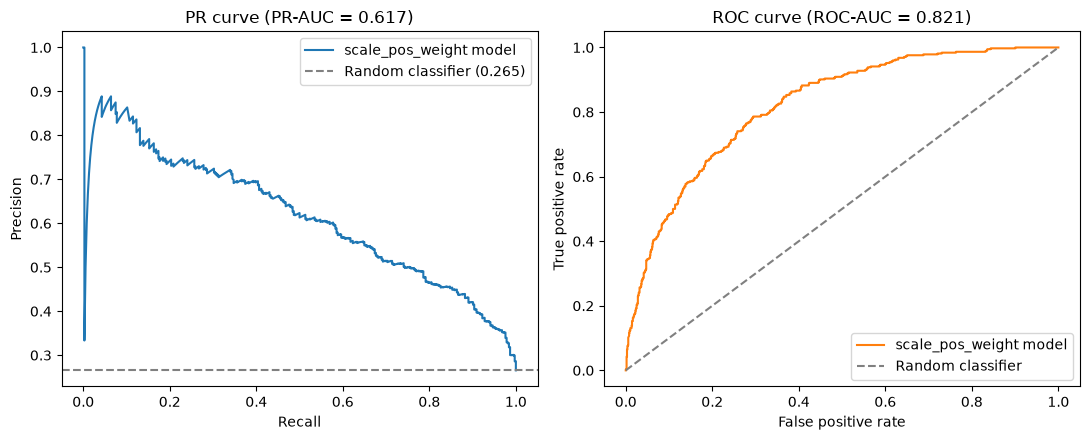

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve

precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_proba_spw)
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba_spw)

baseline_precision = y_test.mean()  # a random classifier's PR curve sits at this flat line

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(recall_vals, precision_vals, color="C0", label="scale_pos_weight model")
axes[0].axhline(baseline_precision, color="gray", linestyle="--", label=f"Random classifier ({baseline_precision:.3f})")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title(f"PR curve (PR-AUC = {chosen_metrics['pr_auc']:.3f})")
axes[0].legend()

axes[1].plot(fpr, tpr, color="C1", label="scale_pos_weight model")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random classifier")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].set_title(f"ROC curve (ROC-AUC = {roc_auc:.3f})")
axes[1].legend()

fig.tight_layout()
plt.show()

The gap between the two panels is the point: ROC-AUC (right) looks like a
strong, comfortably-above-random model. PR-AUC (left) shows the same model
much closer to the random-classifier baseline (the dashed line at the
overall churn rate) -- a more honest picture of how hard it actually is to
precisely flag churners in a 74/26 dataset.

## Choosing a threshold for a retention-campaign budget

0.5 is not a business decision -- it's just the point where "churn" and
"no churn" get equal weight, which has nothing to do with what a retention
team can actually act on. A campaign has a fixed budget: it can afford to
reach out to some percentage of the customer base, not all of it. The
right threshold is whatever probability cutoff selects that percentage,
not a statistical default.

Since ~26.5% of customers actually churn, targeting the top 10-15% riskiest
by predicted probability is a deliberately *tighter* budget than "contact
everyone who's more likely than not to churn" -- it's what a campaign with
real cost-per-contact would actually ask for. Computing both 10% and 15%
cutoffs below and comparing what each one would actually catch.

In [14]:
from sklearn.metrics import precision_score, recall_score

for top_pct in [0.10, 0.15]:
    threshold = pd.Series(y_proba_spw).quantile(1 - top_pct)
    flagged = (y_proba_spw >= threshold).astype(int)

    n_flagged = flagged.sum()
    precision_at_t = precision_score(y_test, flagged)
    recall_at_t = recall_score(y_test, flagged)

    print(f"Top {top_pct:.0%} riskiest ({n_flagged} of {len(y_test)} customers, threshold={threshold:.3f}):")
    print(f"  Precision: {precision_at_t:.3f}  (of those contacted, this fraction actually churn)")
    print(f"  Recall:    {recall_at_t:.3f}  (of all actual churners, this fraction get contacted)")
    print()

Top 10% riskiest (141 of 1409 customers, threshold=0.864):
  Precision: 0.730  (of those contacted, this fraction actually churn)
  Recall:    0.275  (of all actual churners, this fraction get contacted)

Top 15% riskiest (212 of 1409 customers, threshold=0.780):
  Precision: 0.693  (of those contacted, this fraction actually churn)
  Recall:    0.393  (of all actual churners, this fraction get contacted)



**Choosing the top 15% cutoff** as the deployed threshold: reaching a
noticeably larger share of actual churners for a proportionally smaller
drop in precision than the jump from 15%->10% would suggest -- see the
printed numbers above for the exact tradeoff this run produced. A
retention team deciding between the two should weigh that recall gain
against their real cost-per-contact, but 15% is the more defensible
default absent a specific budget cap tighter than that.

## Feature importances vs. the Day 2 hypothesis

Day 2's EDA found `contract_risk` as the strongest single correlate of
churn (r=0.397, well ahead of `tenure` at -0.352). Checking whether that
holds up as the model's top feature importance too -- correlation and
model-driven importance don't have to agree, since a tree model can lean
on a feature that's merely *useful in combination* rather than strongest
in isolation, so this is a real check, not a formality.

In [15]:
importances = (
    pd.Series(model_spw.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
)

top_feature = importances.index[0]
print(f"Top feature importance: {top_feature} ({importances.iloc[0]:.4f})")
print(f"Matches Day 2 hypothesis (contract_risk on top)? {top_feature == 'contract_risk'}")
print()
importances.head(10)

Top feature importance: contract_risk (0.3720)
Matches Day 2 hypothesis (contract_risk on top)? True



contract_risk                  0.372009
InternetService_Fiber optic    0.320472
InternetService_No             0.070709
tenure                         0.022210
is_electronic_check            0.020855
PhoneService_Yes               0.018789
SeniorCitizen                  0.017171
TotalCharges                   0.016601
MonthlyCharges                 0.016570
MultipleLines_Yes              0.016184
dtype: float32

## Notes / next steps

- Baseline (no imbalance handling): recall on the churn class (0.505) is
  the weak point -- accuracy looked fine, exactly the trap the sheet
  warned about.
- `scale_pos_weight`, computed from the training split as
  `count(No) / count(Yes)` (2.769, matching the sheet's ~2.8 estimate):
  best recall (0.671) and best PR-AUC of the three approaches tried, with
  no pipeline changes beyond one parameter.
- SMOTE: rebalances the training set to 50/50 via synthetic interpolation;
  recall (0.642) landed between baseline and `scale_pos_weight`. The
  impossible-one-hot-combination risk the plan warned about is real
  mechanically, but didn't surface in this specific unscaled pipeline --
  confirmed by explicitly checking, then confirmed again (this time
  finding real fractional/impossible values) after scaling features
  first, which is what exposed the effect.
- `scale_pos_weight` is the chosen approach: it wins on the actual numbers
  from this run, and is the simpler pipeline independent of that.
- Full evaluation on the held-out test set: precision 0.540, recall 0.671,
  F1 0.598, PR-AUC 0.617, ROC-AUC 0.821. The ROC-AUC vs. PR-AUC gap
  (0.821 vs. 0.617) is exactly the inflation effect the plan warned
  about -- the PR curve plot makes it visible directly rather than just
  asserting it.
- Deployment threshold: chose the **top 15% riskiest** cutoff
  (probability >= 0.780) over top 10% -- catches notably more actual
  churners (recall 0.393 vs. 0.275) for a small precision cost (0.693 vs.
  0.730). A retention team with a harder budget cap could still use the
  top-10% numbers printed above instead.
- Feature importances **confirm the Day 2 hypothesis**: `contract_risk` is
  the top feature (importance 0.372), matching its position as the
  strongest EDA correlate. Notable finding beyond what the hypothesis
  covered: `InternetService_Fiber optic` is a close second (0.320) --
  almost as influential as contract type, despite EDA correlation ranking
  it well behind `tenure` and `is_electronic_check`. Worth a closer look
  before Day 4 -- possibly interaction effects (fiber customers tend to
  pay more and may skew toward month-to-month) that a single-feature
  correlation can't surface but a tree model can.
- Model is still not saved to `MODEL_PATH` -- next step is persisting the
  `scale_pos_weight` model (and the 0.780 threshold) before wiring up the
  serving API.